# 🔮 Telco Customer Churn Prediction (分类实战)

## 🎯 商业背景 (Business Context)
> 你是一家电信公司的 Senior Data Analyst。公司月均流失率 **26.5%**，
> 获客成本是留客成本的 **5 倍**。目标：识别高风险流失用户，精准干预。

## 🛠 技术栈
- **Baseline**: Logistic Regression (LR)
- **进阶**: XGBoost (Gradient Boosting)
- **评估**: AUC-ROC, Classification Report, ROC 曲线
- **解释**: SHAP (SHapley Additive exPlanations)

## 📖 面试关联
- 简历项目: "构建 XGBoost 分类模型预测用户流失意图"
- 本项目验证: LR → XGBoost 的迭代思路 + 不平衡数据处理 + SHAP 归因

## 🏆 目标成绩
| 模型 | AUC 目标 |
| :--- | :------- |
| LR Baseline | ≥ 0.82 |
| XGBoost | ≥ 0.84 |

---
## 模块 0: 函数加油站 (Function Cheat Sheet)

| 函数 | 大白话 | 语法 | SQL 类比 |
| :--- | :----- | :--- | :------- |
| `pd.to_numeric(s, errors='coerce')` | 把文本转数字，转不了的变 NaN | `pd.to_numeric(df['col'], errors='coerce')` | `CAST(col AS FLOAT)` |
| `pd.get_dummies(df, columns=[...])` | 多分类 → 多列 0/1 | `pd.get_dummies(df, columns=['A'], drop_first=True)` | `CASE WHEN` 多列 |
| `train_test_split(X, y, stratify=y)` | 按比例拆分训练/测试集 | `stratify=y` 保证两边 Churn 比例一致 | 随机抽样 + 分层 |
| `StandardScaler().fit_transform(X)` | Z-score 标准化 (均值0方差1) | `scaler.fit(train)` → `scaler.transform(test)` | `(x - AVG(x)) / STDDEV(x)` |
| `roc_auc_score(y_true, y_prob)` | 模型把正样本排在负样本前面的概率 | 需传入 `predict_proba()[:, 1]` | — |
| `shap.TreeExplainer(model)` | 用 Shapley 值解释每个特征的贡献 | `explainer.shap_values(X)` | — |

---
## 1. 数据加载 (Data Loading)

In [ ]:
# 数据导入 (Kaggle API)
# 强制使用绝对路径调用 kaggle
# !kaggle datasets download blastchar/telco-customer-churn --path ./data --unzip -f WA_Fn-UseC_-Telco-Customer-Churn.csv

./Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
WA_Fn-UseC_-Telco-Customer-Churn.csv: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform

# 1. 忽略烦人的警告
warnings.filterwarnings('ignore')

# 2. Pandas 显示设置 (破解行列显示限制)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.3f' % x) # 避免科学计数法

# 2. 绘图设置 (高清 + 样式)
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.5)

# 3. 解决中文乱码 (Mac/Windows 自适应) 🇨🇳
if platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS'] # Mac专用
else:
    plt.rcParams['font.sans-serif'] = ['SimHei'] # Windows专用

plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

In [5]:
# 加载数据
df = pd.read_csv('./data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"数据: {df.shape[0]} 行, {df.shape[1]} 列")
df.head(3)

数据: 7043 行, 21 列


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes


In [3]:
# 快速 EDA
print("=" * 50)
print("数据类型:")
print(df.dtypes.value_counts())
print("\n缺失值:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nChurn 分布:")
print(df['Churn'].value_counts(normalize=True))

数据类型:
str        18
int64       2
float64     1
Name: count, dtype: int64

缺失值:
Series([], dtype: int64)

Churn 分布:
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [6]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000,7043,7043,7043.000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043.000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,3,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162,NaN,NaN,32.371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.762,NaN,NaN
std,NaN,NaN,0.369,NaN,NaN,24.559,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090,NaN,NaN
min,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250,NaN,NaN
25%,NaN,NaN,0.000,NaN,NaN,9.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500,NaN,NaN
50%,NaN,NaN,0.000,NaN,NaN,29.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350,NaN,NaN
75%,NaN,NaN,0.000,NaN,NaN,55.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850,NaN,NaN


---
## 2. 数据清洗 (Data Cleaning)

> 📖 **陷阱提示**: `TotalCharges` 列看起来是数字，但实际是 object 类型（含空格字符串），需特殊处理。

In [ ]:
# TODO: 数据清洗
# 提示:
# 1. 删除 customerID (对预测无用)
# 2. TotalCharges 有空格字符串, 用 pd.to_numeric(errors='coerce') 转数值
# 3. 空值用中位数填充: df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# 4. Churn: Yes/No → 1/0

In [7]:
df.columns = df.columns.str.lower()

In [11]:
df['totalcharges'] = pd.to_numeric(df['totalcharges'],errors='coerce')
df['totalcharges'] = df['totalcharges'].fillna(df['totalcharges'].median())
df[df['totalcharges'].isnull()]


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn


In [14]:
df['churn'] = np.where(df['churn'] == 'Yes',1,0)
df['churn'].value_counts()

churn
0    5174
1    1869
Name: count, dtype: int64

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   str    
 4   dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   str    
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   str    
 17  paymen

In [ ]:
str_cols = df.select_dtypes(include = ['str']).columns.tolist()
if 'customerid' in str_cols : str_cols.remove('customerid')

df = pd.get_dummies(df,columns=str_cols,drop_first=True)


,customerid,seniorcitizen,tenure,monthlycharges,totalcharges,churn,gender_Male,partner_Yes,dependents_Yes,phoneservice_Yes,multiplelines_No phone service,multiplelines_Yes,internetservice_Fiber optic,internetservice_No,onlinesecurity_No internet service,onlinesecurity_Yes,onlinebackup_No internet service,onlinebackup_Yes,deviceprotection_No internet service,deviceprotection_Yes,techsupport_No internet service,techsupport_Yes,streamingtv_No internet service,streamingtv_Yes,streamingmovies_No internet service,streamingmovies_Yes,contract_One year,contract_Two year,paperlessbilling_Yes,paymentmethod_Credit card (automatic),paymentmethod_Electronic check,paymentmethod_Mailed check
count,7043,7043.000,7043.000,7043.000,7043.000,7043.000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,7590-VHVEG,NaN,NaN,NaN,NaN,NaN,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
freq,1,NaN,NaN,NaN,NaN,NaN,3555,3641,4933,6361,6361,4072,3947,5517,5517,5024,5517,4614,5517,4621,5517,4999,5517,4336,5517,4311,5570,5348,4171,5521,4678,5431
mean,NaN,0.162,32.371,64.762,2281.917,0.265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,0.369,24.559,30.090,2265.270,0.442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,0.000,0.000,18.250,18.800,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,0.000,9.000,35.500,402.225,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,0.000,29.000,70.350,1397.475,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,0.000,55.000,89.850,3786.600,1.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   customerid                             7043 non-null   str    
 1   seniorcitizen                          7043 non-null   int64  
 2   tenure                                 7043 non-null   int64  
 3   monthlycharges                         7043 non-null   float64
 4   totalcharges                           7043 non-null   float64
 5   churn                                  7043 non-null   int64  
 6   gender_Male                            7043 non-null   bool   
 7   partner_Yes                            7043 non-null   bool   
 8   dependents_Yes                         7043 non-null   bool   
 9   phoneservice_Yes                       7043 non-null   bool   
 10  multiplelines_No phone service         7043 non-null   bool   
 11  multiplelines_Y

In [ ]:
num_cols = df.select_dtypes(include = ['number']).columns.tolist()
if 'churn' in num_cols: num_cols.remove('churn')

n_features= len(num_cols)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(15,4 * n_rows))
for i ,col in enumerate(num_cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.boxplot(data=df,x='churn',y=col)
    plt.title(col)

plt.tight_layout()

<Axes: >

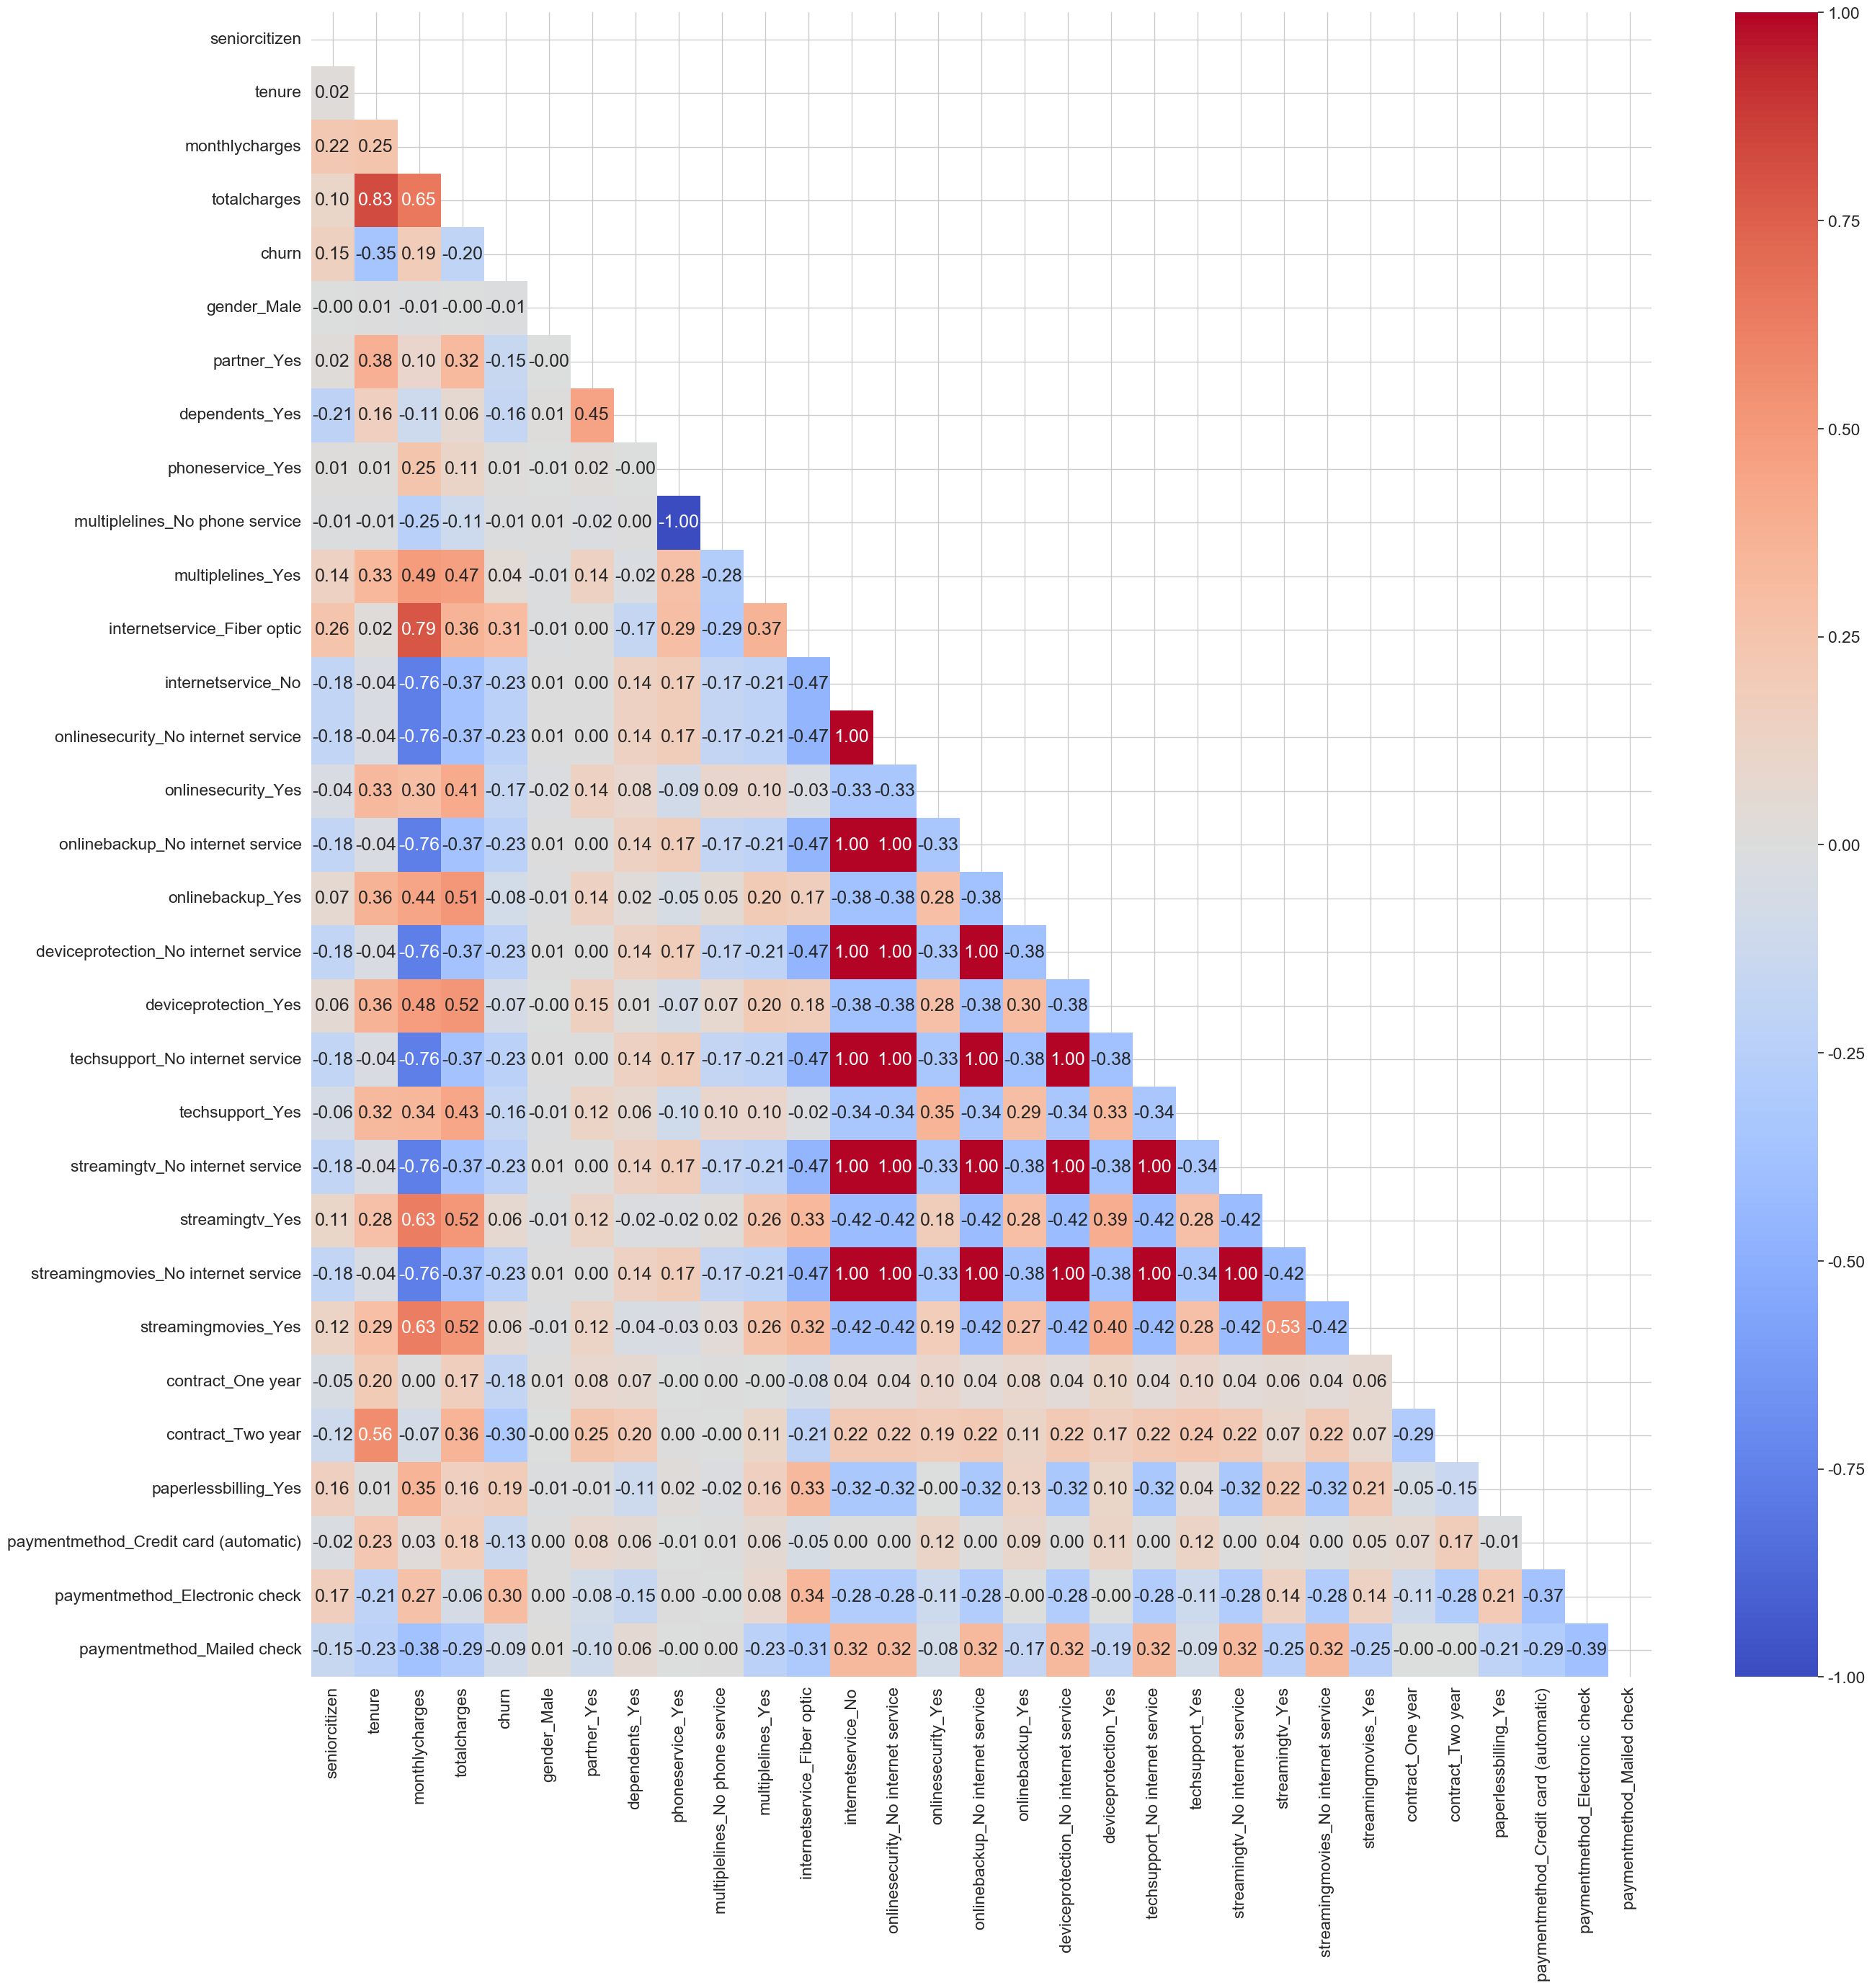

In [33]:
plt.figure(figsize=(30,30))
df1= df.drop(columns=['customerid'])
corr = df1.corr()
sns.heatmap(corr,annot = True,cmap = 'coolwarm',fmt = '.2f',
            mask = np.triu(np.ones_like(corr,dtype=bool)))

---
## 3. 特征编码 (Feature Encoding)

> 📖 原理速记:
> - **二分类**: Yes/No → 1/0 (简单映射)
> - **多分类**: One-Hot Encoding (每个类别变成一列, `drop_first=True` 避免共线性)
> - **数值型**: 不需要编码 (tenure, MonthlyCharges, TotalCharges)

In [ ]:
# TODO: 特征编码
# 提示:
# 1. 二分类列 (Yes/No → 1/0): Partner, Dependents, PhoneService, PaperlessBilling
#    别忘了 gender (Male/Female → 1/0)
# 2. 多分类列 (One-Hot): MultipleLines, InternetService, OnlineSecurity, OnlineBackup,
#    DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaymentMethod
#    用 pd.get_dummies(df, columns=[...], drop_first=True)



---
## 4. 数据切分 (Train/Test Split)

> 📖 原理速记:
> - `stratify=y`: 确保训练集和测试集的 Churn 比例一致 (Stratified Split)
> - 这就是 **Stratified K-Fold** 的核心思想: 保持类别分布一致

In [ ]:
# TODO: 数据切分
# 提示:
# X = df.drop(columns=['Churn'])
# y = df['Churn']
# ⚠️ stratify=y 保持 Churn 比例一致!

from sklearn.model_selection import train_test_split

X = df1.drop(columns=['churn'])
y = df1['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


---
## 5. Baseline: Logistic Regression

> 📖 原理速记 (面试必问!):
> - **Sigmoid 函数**: 把线性组合 z = w₁x₁ + w₂x₂ + ... 映射到 (0,1) 概率
> - **权重含义**: wᵢ > 0 → xᵢ 越大, 流失概率越高
> - **为什么要 Scale?** LR 用梯度下降优化, 特征尺度不一致会导致收敛慢
> - **L1 正则 (Lasso)**: 让部分权重变成 0 → 自动特征选择
> - **L2 正则 (Ridge)**: 让所有权重变小 → 防过拟合

In [43]:
from statsmodels.iolib.summary import summary
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # ← 只 transform，不 fit

model_lr = LogisticRegression(
    random_state = RANDOM_STATE
)

model_lr.fit(X_train_scaled,y_train)

lr_pred = model_lr.predict_proba(X_test_scaled)[:,1]
lr_auc = roc_auc_score(y_test,lr_pred)

print(f'Logistic Regression AUC: {lr_auc:.6f}')

Logistic Regression AUC: 0.841585


---
## 6. 进阶: XGBoost

> 📖 原理速记:
> - `scale_pos_weight`: 处理不平衡数据 (正样本少, 给正样本更高权重)
> - `eval_metric='auc'`: 用 AUC 作为 Early Stopping 的标准
> - **为什么 XGBoost 不需要 Scale?** 因为 Tree 按"阈值"分裂, 不受特征尺度影响
> - **Boosting 本质**: 每棵新树拟合上一棵树的**残差** → 降低偏差 (Bias)

In [47]:
# TODO: XGBoost
# 提示:
import xgboost as xgb
from xgboost import XGBClassifier
#
# 计算不平衡权重:
SCALE_POS_WEIGHT = len(y_train[y_train==0]) / len(y_train[y_train==1])
#
xgb = XGBClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=SCALE_POS_WEIGHT,
    early_stopping_rounds=20,
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric='auc'
)
#
# ⚠️ XGBoost 用原始数据, 不需要 Scale!
xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=0)
#
xgb_pred = xgb.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_pred)

diff = xgb_auc - lr_auc
print(f'XGBoost AUC: {xgb_auc:.6f}')
print(f'xgb auc vs lr auc: {diff:.6f}')


XGBoost AUC: 0.847095
xgb auc vs lr auc: 0.005510


---
## 7. ROC 曲线对比 (LR vs XGBoost)

> 📖 面试必知:
> - **AUC = 模型把正样本排在负样本前面的概率**
> - AUC=0.5 = 随机猜测, AUC=1.0 = 完美分类
> - ROC 曲线越靠近左上角越好

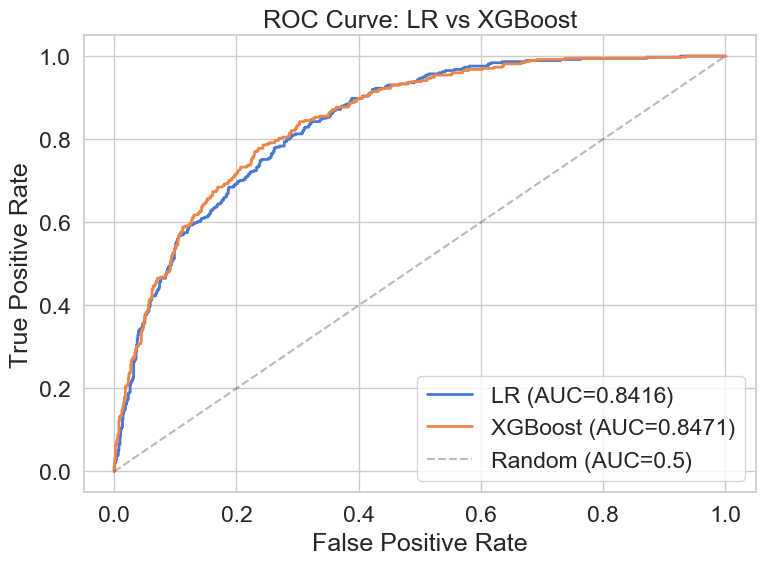

In [48]:
# TODO: ROC 曲线
# 提示:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# LR ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred)
ax.plot(fpr_lr, tpr_lr, label=f'LR (AUC={lr_auc:.4f})', linewidth=2)

# XGBoost ROC
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred)
ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={xgb_auc:.4f})', linewidth=2)

ax.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: LR vs XGBoost')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()



---
## 8. SHAP 归因分析 (模型解释)

> 📖 **面试重点** (简历写了 SHAP，必须说清楚):
> - SHAP 基于博弈论的 **Shapley Value**：每个特征对预测的"边际贡献"
> - 与 `feature_importances_` 的区别：SHAP 给出**方向** (正/负影响) + **重要性**
> - **面试话术**: "Feature Importance 只告诉你哪个特征重要，SHAP 还告诉你它怎么影响预测——比如 tenure 越长，SHAP 值越负（越不容易流失）。"

In [49]:
# TODO: SHAP 分析
# 提示:
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary Plot (全局概览)
shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.title('SHAP Summary Plot (XGBoost)')
plt.tight_layout()
plt.show()

# Bar Plot (重要性排名)
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=10, show=False)
plt.title('SHAP Feature Importance (Top 10)')
plt.tight_layout()
plt.show()



ValueError: could not convert string to float: '[5E-1]'

---
## 9. Classification Report + 评估

> 📖 面试话术:
> - **Precision (查准率)**: 模型预测为流失的用户，有多少确实流失了？
> - **Recall (查全率)**: 实际流失的用户，模型抓住了多少？
> - **业务决策**: 挽留成本低 → 要高 Recall（宁可多打几个电话）；挽留成本高 → 要高 Precision（别浪费资源）

In [50]:
# TODO: Classification Report
# 提示:
from sklearn.metrics import classification_report

xgb_pred_label = (xgb_pred >= 0.5).astype(int)
print("📊 XGBoost Classification Report:")
print(classification_report(y_test, xgb_pred_label, target_names=['Not Churn', 'Churn']))



📊 XGBoost Classification Report:
              precision    recall  f1-score   support

   Not Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



---
## 10. 结论 & 面试话术

> 📌 **完成后请自己填写以下模板** (用你的实际数据):
>
> 1. **模型选型**: "我用 LR 做 Baseline (AUC ___), 再用 XGBoost (AUC ___) 做 Refinement。LR 胜在可解释性 (权重直接看影响方向), XGBoost 胜在非线性捕捉能力。"
>
> 2. **不平衡数据处理**: "Churn 率 26.5%, 用 `scale_pos_weight` 给少数类更高权重, 避免模型偏向预测 Not Churn。"
>
> 3. **SHAP 洞察**: "SHAP 分析显示 ___ 是最重要的特征, 而且 ___ 方向的用户流失风险最高。建议业务侧 ___。"
>
> 4. **LR vs XGBoost Scale 问题**: "LR 用梯度下降优化, 特征尺度不一致导致 loss landscape 扭曲; Tree 模型按阈值分裂, 本质是 Rank, 不受绝对值影响。"

In [ ]:
# TODO: 面试话术 (用你的实际数据填写)
# print("📌 面试话术:")
# print(f"1. LR AUC: {lr_auc:.4f} → XGBoost AUC: {xgb_auc:.4f}")
# print(f"2. 数据: {df.shape[0]} 用户, Churn 率 {y.mean():.1%}")
# print(f"3. Top 3 SHAP 特征: ...")
# print(f"4. 业务建议: ...")



---

# 📖 参考答案 (Agent Reference Code)

> ⚠️ **先自己写完再看！**
> 目标: AUC ≥ 0.82  |  Agent 参考成绩: **LR AUC ~0.84 → XGBoost AUC ~0.85**

In [ ]:
# ===== 参考: 2. 数据清洗 =====
# df.drop(columns=['customerID'], inplace=True)
# df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
# df['Churn'] = (df['Churn'] == 'Yes').astype(int)
# print(f"Churn 率: {df['Churn'].mean():.1%}")

In [ ]:
# ===== 参考: 3. 特征编码 =====
# binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
# for col in binary_cols:
#     df[col] = (df[col] == 'Yes').astype(int)
# df['gender'] = (df['gender'] == 'Male').astype(int)
#
# multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
#               'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
#               'Contract', 'PaymentMethod']
# df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
# print(f"编码后: {df.shape[1]} 列")

In [ ]:
# ===== 参考: 4. 数据切分 =====
# from sklearn.model_selection import train_test_split
# X = df.drop(columns=['Churn'])
# y = df['Churn']
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )
# print(f"Train: {len(X_train)} (Churn率 {y_train.mean():.1%})")
# print(f"Test:  {len(X_test)} (Churn率 {y_test.mean():.1%})")

In [ ]:
# ===== 参考: 5. LR Baseline =====
# from sklearn.preprocessing import StandardScaler
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import roc_auc_score
#
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)
#
# lr = LogisticRegression(max_iter=1000, random_state=42)
# lr.fit(X_train_scaled, y_train)
#
# lr_pred = lr.predict_proba(X_test_scaled)[:, 1]
# lr_auc = roc_auc_score(y_test, lr_pred)
# print(f"📊 LR Baseline AUC: {lr_auc:.4f}")

In [ ]:
# ===== 参考: 6. XGBoost =====
# from xgboost import XGBClassifier
#
# SCALE_POS_WEIGHT = len(y_train[y_train==0]) / len(y_train[y_train==1])
#
# xgb = XGBClassifier(
#     n_estimators=200, max_depth=4, learning_rate=0.1,
#     subsample=0.8, colsample_bytree=0.8,
#     scale_pos_weight=SCALE_POS_WEIGHT,
#     early_stopping_rounds=20,
#     random_state=42, n_jobs=-1, eval_metric='auc'
# )
# xgb.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=0)
#
# xgb_pred = xgb.predict_proba(X_test)[:, 1]
# xgb_auc = roc_auc_score(y_test, xgb_pred)
# print(f"📊 LR AUC: {lr_auc:.4f} → XGBoost AUC: {xgb_auc:.4f} (提升 +{xgb_auc-lr_auc:.4f})")

In [ ]:
# ===== 参考: 7. ROC 曲线 =====
# from sklearn.metrics import roc_curve
# import matplotlib.pyplot as plt
#
# fig, ax = plt.subplots(figsize=(8, 6))
# fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_pred)
# ax.plot(fpr_lr, tpr_lr, label=f'LR (AUC={lr_auc:.4f})', linewidth=2)
# fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred)
# ax.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={xgb_auc:.4f})', linewidth=2)
# ax.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random (AUC=0.5)')
# ax.set_xlabel('False Positive Rate')
# ax.set_ylabel('True Positive Rate')
# ax.set_title('ROC Curve: LR vs XGBoost')
# ax.legend(loc='lower right')
# plt.tight_layout()
# plt.show()

In [ ]:
# ===== 参考: 8. SHAP =====
# import shap
#
# explainer = shap.TreeExplainer(xgb)
# shap_values = explainer.shap_values(X_test)
#
# # Summary Plot
# shap.summary_plot(shap_values, X_test, max_display=15, show=False)
# plt.title('SHAP Summary Plot')
# plt.tight_layout()
# plt.show()
#
# # Bar Plot
# shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=10, show=False)
# plt.title('SHAP Feature Importance (Top 10)')
# plt.tight_layout()
# plt.show()

In [ ]:
# ===== 参考: 9. Classification Report =====
# from sklearn.metrics import classification_report
#
# xgb_pred_label = (xgb_pred >= 0.5).astype(int)
# print("📊 XGBoost Classification Report:")
# print(classification_report(y_test, xgb_pred_label, target_names=['Not Churn', 'Churn']))